# A/B-тест: влияние бонуса на конверсию пользователей TikTok

## Дизайн эксперимента

### Контекст и цель
Из исторического анализа мы знаем, что TikTok — самый неэффективный канал: он привлекает много пользователей, но доля платящих среди них крайне низкая (менее 4%). Команда предположила, что стимулирование первой покупки может повысить конверсию.

**Цель эксперимента** — проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей, пришедших из TikTok.

**Гипотеза:** бонус увеличит конверсию в первую покупку.

### Формат эксперимента
- **Тип:** сплит-роллинг (rolling split) — новые пользователи TikTok случайным образом распределяются между группами по дате регистрации.
- **Группы:**
  - Контрольная (A): пользователи без бонуса.
  - Тестовая (B): пользователи с бонусом на первую покупку.
- **Период проведения:** 3 недели.

### Ключевые метрики
- **Целевая метрика:** конверсия в первую покупку (доля пользователей, совершивших заказ).
- **Вспомогательные метрики:** ARPU, ARPPU, AOV (чтобы оценить, не ухудшилось ли качество платящих).
- **Барьерная метрика:** общая выручка от пользователей TikTok (чтобы убедиться, что бонус не навредил бизнесу).

**Важное замечание:** эксперимент запущен без предварительного расчёта мощности и MDE (minimum detectable effect) из-за срочности задачи. Это ограничение будет учтено при интерпретации результатов.

## Данные и предобработка
В проекте используются данные эксперимента: заказы, пользователи, события, маркетинговые затраты и сплит-таблица с группами. Подробное описание структуры таблиц и ссылки на файлы — в `data_schema.md`.

В этом разделе:
- загрузим данные и проверим их на пропуски, дубликаты и типы данных;
- создадим дополнительные признаки для анализа (агрегированный идентификатор заказа, комиссия маркетплейса);
- отфильтруем период эксперимента (6–26 января 2025 года) для минимизации влияния праздничных дней.

In [1]:
# Импортируем библиотеки
try:
    import pandas as pd
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    from scipy.stats import ttest_ind
    from statsmodels.stats.proportion import proportions_ztest
    from scipy.stats import chi2_contingency
    import numpy as np
except ImportError as e:
    print(f"Ошибка импорта: {e}")
    print("Установите необходимые библиотеки: pip install pandas plotly scipy statsmodels numpy")
    raise SystemExit

In [ ]:
# Импортируем данные
pa_marketplace_orders_AB = pd.read_csv('https://.../datasets/pa_marketplace_orders_AB.csv',
                                    parse_dates=['order_date', 'order_week', 'order_month'])
pa_marketplace_campaign_costs = pd.read_csv('https://.../datasets/pa_marketplace_campaign_costs.csv',
                                            usecols=['acq_channel', 'spend_month', 'budget'],
                                            parse_dates=['spend_month'])
pa_marketplace_users_AB = pd.read_csv('https://.../datasets/pa_marketplace_users_AB.csv',
                                  parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
pa_marketplace_events_AB = pd.read_csv('https://.../datasets/pa_marketplace_events_AB.csv',
                                   parse_dates=['event_date', 'event_week', 'event_month'])
pa_marketplace_AB_split_users = pd.read_csv('https://.../datasets/pa_marketplace_AB_split_users.csv')

In [3]:
# Создаем словарь датафреймов
tables_ab ={'pa_marketplace_orders_AB': pa_marketplace_orders_AB,
       'pa_marketplace_campaign_costs': pa_marketplace_campaign_costs,
       'pa_marketplace_users_AB': pa_marketplace_users_AB,
       'pa_marketplace_events_AB': pa_marketplace_events_AB,
           'pa_marketplace_AB_split_users': pa_marketplace_AB_split_users}

# Создаем функцию для вывода краткой информации
def dataframe_summary(name, df):
    summary = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.values,
        'non_null': df.count().values,
        'nulls': df.isnull().sum().values,
        'nulls_%': (df.isnull().sum() / len(df) * 100).round(2).values,
        'unique': df.nunique().values
    })
    return summary

# Выводим информацию по датафреймам
for name, df in tables_ab.items():
    print(f'Датафрейм: {name} (строк - {len(df)}, колонок - {len(df.columns)})')
    display(dataframe_summary(name, df))
    display(df.head())
    print()

Датафрейм: pa_marketplace_orders_AB (строк - 33280, колонок - 10)


,column,dtype,non_null,nulls,nulls_%,unique
0,order_id,int64,33280,0,0.0,33080
1,user_id,int64,33280,0,0.0,9566
2,order_date,str,33280,0,0.0,19114
3,product_name,str,33280,0,0.0,200
4,quantity,int64,33280,0,0.0,3
5,unit_price,float64,33280,0,0.0,400
6,total_price,float64,33280,0,0.0,1158
7,category_name,str,33280,0,0.0,25
8,order_week,datetime64[us],33280,0,0.0,56
9,order_month,datetime64[us],33280,0,0.0,13


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52.000,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52.000,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38.000,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01



Датафрейм: pa_marketplace_campaign_costs (строк - 88, колонок - 3)


,column,dtype,non_null,nulls,nulls_%,unique
0,acq_channel,str,88,0,0.0,7
1,spend_month,datetime64[us],88,0,0.0,13
2,budget,float64,88,0,0.0,88


...

,column,dtype,non_null,nulls,nulls_%,unique
0,event_id,int64,831231,0,0.00,813509
1,user_id,int64,831231,0,0.00,23948
2,event_date,datetime64[us],831231,0,0.00,814212
3,event_type,str,831231,0,0.00,15
4,os,str,831231,0,0.00,4
5,device,str,831231,0,0.00,3
6,product_name,str,409054,422177,50.79,200
7,event_week,datetime64[us],831231,0,0.00,56
8,event_month,datetime64[us],831231,0,0.00,13


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01 15:23:56,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01 15:24:01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01 15:24:10,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01



Датафрейм: pa_marketplace_AB_split_users (строк - 2968, колонок - 2)


,column,dtype,non_null,nulls,nulls_%,unique
0,user_id,int64,2968,0,0.0,2968
1,group,str,2968,0,0.0,2


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


In [4]:
# Преобразуем к дате order_date
pa_marketplace_orders_AB['order_date'] = pd.to_datetime(pa_marketplace_orders_AB['order_date'],
                                                        format='ISO8601')
# Преобразуем тип данных к Category
pa_marketplace_orders_AB[['product_name', 'category_name']] = pa_marketplace_orders_AB[['product_name', 'category_name']].astype('category')
pa_marketplace_campaign_costs['acq_channel'] = pa_marketplace_campaign_costs['acq_channel'].astype('category')
pa_marketplace_users_AB[['gender', 'region', 'acq_channel', 'buyer_segment']] = pa_marketplace_users_AB[['gender', 'region',
                                                                                                   'acq_channel', 'buyer_segment']].astype('category')
pa_marketplace_events_AB[['event_type', 'os', 'device', 'product_name']] = pa_marketplace_events_AB[['event_type', 'os',
                                                                                               'device', 'product_name']].astype('category')
pa_marketplace_AB_split_users['group'] = pa_marketplace_AB_split_users['group'].astype('category')

# Оптимизируем численные типы данных
for key, value in tables_ab.items():
    for col in value.columns:
        if pd.api.types.is_integer_dtype(value[col]):
            value[col] = pd.to_numeric(value[col], downcast='integer')
        elif pd.api.types.is_float_dtype(value[col]):
             value[col] = pd.to_numeric(value[col], downcast='float')

In [5]:
# Проверяем группы A/B-теста пользователей
print(f"Тестовые группы: {list(pa_marketplace_AB_split_users['group'].unique())}")
print(f"Каналы привлечения пользователей: {list(pa_marketplace_users_AB['acq_channel'].unique())}")

Тестовые группы: ['control', 'treatment']
Каналы привлечения пользователей: ['TikTok']


In [6]:
# Проверяем наличие полных дубликатов
for key, value in tables_ab.items():
    print(f"{key}: {value.duplicated(keep=False).sum()} полных дубликатов")

pa_marketplace_orders_AB: 0 полных дубликатов
pa_marketplace_campaign_costs: 0 полных дубликатов
pa_marketplace_users_AB: 0 полных дубликатов
pa_marketplace_events_AB: 0 полных дубликатов
pa_marketplace_AB_split_users: 0 полных дубликатов


In [7]:
# Проверка наличия частичных дубликатов
orders_duplicates = pa_marketplace_orders_AB[pa_marketplace_orders_AB.duplicated(subset=['user_id', 'order_date', 'product_name',
                                                                                   'quantity', 'total_price'], keep=False)]
print(f"pa_marketplace_orders_AB: {len(orders_duplicates)} частичных дубликатов")
display(orders_duplicates.head(6))

users_duplicates = pa_marketplace_users_AB[pa_marketplace_users_AB.duplicated(subset=['registration_date', 'age', 'gender',
                                                           'region', 'acq_channel', 'buyer_segment'], keep=False)]
print(f"pa_marketplace_users_AB: {len(users_duplicates)} частичных дубликатов")

users_split_duplicates = pa_marketplace_AB_split_users[pa_marketplace_AB_split_users.duplicated(subset=['user_id'], keep=False)]
print(f"pa_marketplace_AB_split_users: {len(users_split_duplicates)} дубликатов пользователей")

pa_marketplace_orders_AB: 555 частичных дубликатов


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
232,233,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
233,234,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
459,460,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
460,461,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
562,563,420,2024-01-13 19:39:50,Чайник электрический,3,6254.47,18763.41,Товары для кухни,2024-01-08,2024-01-01
563,564,420,2024-01-13 19:39:50,Чайник электрический,3,6254.47,18763.41,Товары для кухни,2024-01-08,2024-01-01


pa_marketplace_users_AB: 0 частичных дубликатов
pa_marketplace_AB_split_users: 0 дубликатов пользователей


- pa_marketplace_orders_AB: обнаружено 555 дубликатов по id пользователя, времени заказа и характеристикам позиции (наименовение товара, количество, цена).<br> Принято решение не удалять дубликаты из-за отсутствия дополнительной информации об особенностях организации и хранения данных.
- pa_marketplace_users_AB: частичные дубликаты не обнаружены
- pa_marketplace_AB_split_users: дубликаты пользователей не обнаружены
- pa_marketplace_campaign_costs и pa_marketplace_events_AB: обработка не выполнялась.

In [8]:
# Проверяем описательные статистики численных признаков
print('pa_marketplace_orders_AB')
display(pa_marketplace_orders_AB[['quantity', 'unit_price', 'total_price']].describe())
print("\npa_marketplace_users_AB['age']")
display(pa_marketplace_users_AB['age'].describe())

pa_marketplace_orders_AB


,quantity,unit_price,total_price
count,33280.000000,33280.000000,33280.000000
mean,2.007903,7008.818957,14077.690767
std,0.819379,8207.293022,18733.542970
min,1.000000,218.820000,218.820000
25%,1.000000,2122.440000,3707.250000
50%,2.000000,4406.630000,7609.350000
75%,3.000000,9395.950000,17700.750000
max,3.000000,63932.380000,191797.140000



pa_marketplace_users_AB['age']


count    22196.000000
mean        44.098261
std         15.277325
min         18.000000
25%         31.000000
50%         44.000000
75%         57.000000
max         70.000000
Name: age, dtype: float64

На основе предположения, что все заказы, оформленные одним пользователем  в один момент времени, являются частями одной корзины, создадим агрегированный идентификатор заказа `agg_order_id` для дальнейшего анализа юнит-экономики.<br>
Также создадим поле с расчетом размера комиссии маркетплейса.

In [9]:
# Создаем дополнительные признаки
# агрегированный заказ
pa_marketplace_orders_AB = pa_marketplace_orders_AB.sort_values(['user_id', 'order_date'])

pa_marketplace_orders_AB['agg_order_id'] = (pa_marketplace_orders_AB
                                            .groupby(['user_id', 'order_date'])
                                            .ngroup() + 1)
# комиссия маркетплейса
pa_marketplace_orders_AB['commission'] = (pa_marketplace_orders_AB['total_price'] * 0.05).round(2)

display(pa_marketplace_orders_AB.head())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,agg_order_id,commission
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1,553.91
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1,567.02
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1,1089.21
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,2,553.91
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,2,104.98


In [10]:
# Проверяем диапазоны дат
print(f"pa_marketplace_orders_AB: c {pa_marketplace_orders_AB['order_date'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_orders_AB['order_date'].max().strftime('%Y-%m-%d')}")
print(f"pa_marketplace_campaign_costs: c {pa_marketplace_campaign_costs['spend_month'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_campaign_costs['spend_month'].max().strftime('%Y-%m-%d')}")
print(f"pa_marketplace_users_AB: c {pa_marketplace_users_AB['registration_date'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_users_AB['registration_date'].max().strftime('%Y-%m-%d')}")
print(f"pa_marketplace_events_AB: c {pa_marketplace_events_AB['event_date'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_events_AB['event_date'].max().strftime('%Y-%m-%d')}")

pa_marketplace_orders_AB: c 2024-01-01 по 2025-01-26
pa_marketplace_campaign_costs: c 2024-01-01 по 2025-01-01
pa_marketplace_users_AB: c 2024-01-01 по 2025-01-26
pa_marketplace_events_AB: c 2024-01-01 по 2025-01-26


Датасеты содержат как исторические данные за 2024 год, так и данные за период проведения A/B-теста.

In [11]:
# Фильтруем данные по пользователям A/B-теста
users_ab_all = pa_marketplace_users_AB.merge(pa_marketplace_AB_split_users, on=['user_id'], how='right').drop('buyer_segment', axis=1)

# Создаем поле с датой регистрации
users_ab_all['reg_dt'] = users_ab_all['registration_date'].dt.normalize()

# Определяем диапазон дат регистрации пользователей теста
print(f"Период данных: c {users_ab_all['reg_dt'].min().strftime('%Y-%m-%d')} по {users_ab_all['reg_dt'].max().strftime('%Y-%m-%d')}")

Период данных: c 2025-01-01 по 2025-01-26


Фактический период доступных данных превышает запланированную длительность эксперимента (3 недели). Для минимизации влияния праздничных дней (1–5 января 2025 года), которые могли исказить поведение пользователей и снизить репрезентативность результатов, в качестве анализируемого периода выбран интервал с 6 по 26 января 2025 года. Данный период соответствует требуемой длительности эксперимента и обеспечивает оценку эффекта бонуса в условиях, приближенных к нормальной рыночной активности.

In [12]:
# Отбираем данные за период 06.01.2025-26.01.2025
users_ab = users_ab_all.query('reg_dt >= "2025-01-06"')
orders_ab = pa_marketplace_orders_AB.query('user_id in @users_ab["user_id"]')
events_ab = pa_marketplace_events_AB.query('user_id in @users_ab["user_id"]')

print(f"Отобрано записей: orders_ab - {len(orders_ab)}, events_ab - {len(events_ab)}, users_ab - {len(users_ab)}")

Отобрано записей: orders_ab - 167, events_ab - 2744, users_ab - 2310


**Итог по разделу**
- Дубликаты: в таблице заказов обнаружено 555 частичных дубликатов (одинаковые `user_id`, `order_date`, `product_name`, `quantity`, `total_price`). Решение — не удалять, а агрегировать в `agg_order_id`, так как это, вероятно, части одной корзины. В остальных таблицах дубликатов не выявлено.
- Типы данных: оптимизированы — категориальные переменные приведены к типу `category`, числовые — к более компактным форматам.
- Диапазоны дат: данные охватывают период с 2024 по январь 2025 года. Для анализа эксперимента выбран интервал с 6 по 26 января 2025 года — это позволило исключить новогодние праздники (1–5 января) и снизить риск искажения результатов.
- Дополнительные признаки: создан `agg_order_id` для агрегации заказов по корзинам и рассчитана комиссия маркетплейса (5% от `total_price`).

## Исследовательский анализ
В этом разделе:
- проверим, можно ли доверять результатам эксперимента: оценим стабильность продукта в период теста и выявим ограничения дизайна (короткое окно наблюдения, rolling split);
- убедимся, что сплитование пользователей выполнено корректно, и группы сопоставимы по ключевым характеристикам (возраст, пол, регион, динамика регистраций);
- оценим влияние бонуса на целевую (конверсия), барьерную (выручка) и вспомогательные (ARPU, ARPPU, AOV) метрики.

### Стабильность продукта в период эксперимента
Для оценки стабильности продукта в период проведения эксперимента и исключения влияния внешних факторов (системные сбои, падение активности, проблемы с оплатой) проанализируем ежедневную динамику ключевых метрик за период с 7 октября 2024 года по 26 января 2025 года.

In [13]:
# Собираем данные для расчета метрик
pa_marketplace_orders_AB['order_dt'] = pa_marketplace_orders_AB['order_date'].dt.normalize()
pa_marketplace_events_AB['event_dt'] = pa_marketplace_events_AB['event_date'].dt.normalize()

start_date = '2024-10-07'

# Фильтруем заказы
daily_orders = (pa_marketplace_orders_AB.query('order_dt >= @start_date')
                .groupby('order_dt', as_index=False)
                .agg(paying_users=('user_id', 'nunique'),
                     cnt_orders=('agg_order_id', 'nunique'),
                     gmv=('total_price', 'sum'),
                     revenue=('commission', 'sum'))
                .rename(columns={'order_dt': 'date'}))


daily_active = (pa_marketplace_events_AB.query('event_dt >= @start_date and event_type not in ("user_login", "user_logout")')
                .groupby('event_dt', as_index=False)['user_id']
                .nunique()
                .rename(columns={'event_dt': 'date', 'user_id': 'active_users'}))

daily_stats = daily_active.merge(daily_orders, on='date', how='outer').fillna(0)

# Расчет метрик
daily_stats['conversion'] = (daily_stats['paying_users'] / daily_stats['active_users']).round(3)
daily_stats['aov'] = (daily_stats['gmv'] / daily_stats['cnt_orders']).replace([float('inf'), -float('inf')], 0).round(2)
daily_stats['arpu'] = (daily_stats['revenue'] / daily_stats['active_users']).round(2)
daily_stats['arppu'] = (daily_stats['revenue'] / daily_stats['paying_users']).replace([float('inf'), -float('inf')], 0).round(2)

# Сортируем
daily_stats = daily_stats.sort_values('date').reset_index(drop=True)

display(daily_stats.head())

,date,active_users,paying_users,cnt_orders,gmv,revenue,conversion,aov,arpu,arppu
0,2024-10-07,296,42,42,766643.52,38332.20,0.142,18253.42,129.50,912.67
1,2024-10-08,312,45,46,927638.21,46381.93,0.144,20166.05,148.66,1030.71
2,2024-10-09,295,45,45,976525.74,48826.33,0.153,21700.57,165.51,1085.03
3,2024-10-10,307,52,52,1516926.49,75846.34,0.169,29171.66,247.06,1458.58
4,2024-10-11,356,48,48,798424.19,39921.24,0.135,16633.84,112.14,831.69


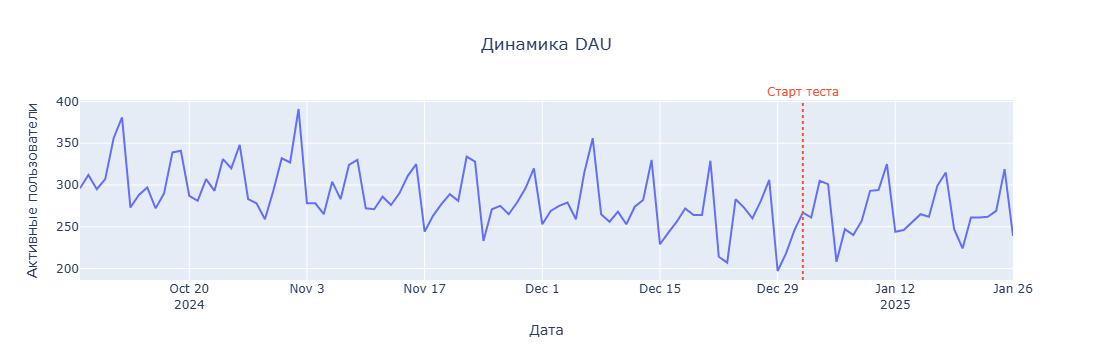

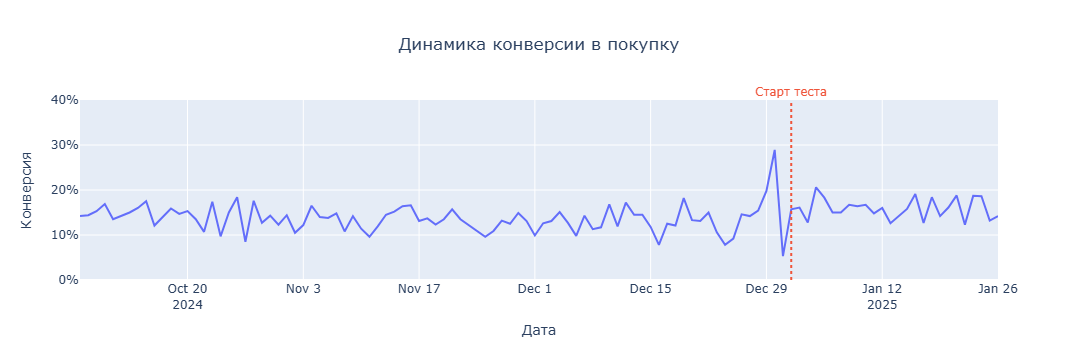

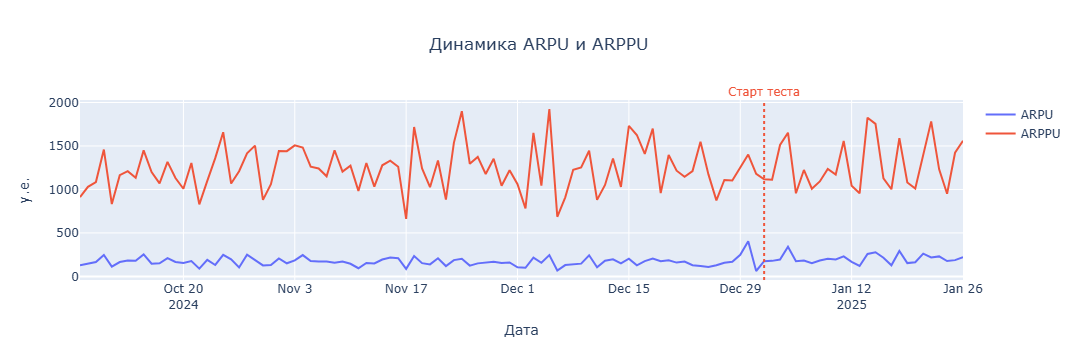

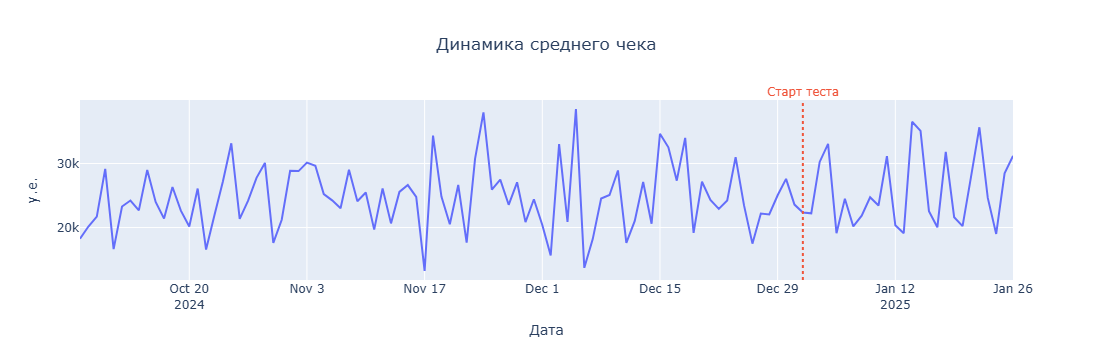

In [14]:
# Визуализируем метрики
# MAU
fig1 = px.line(daily_stats,
               x='date',
               y='active_users',
               title='Динамика DAU',
               labels={'date': 'Дата', 'active_users':'Активные пользователи'})

test_start = pd.to_datetime('2025-01-01')

fig1.add_shape(type='line',
              x0=test_start, 
              x1=test_start,
              y0=0, 
              y1=1,
              yref='paper',
              line=dict(color=px.colors.qualitative.Plotly[1], dash='dot'))

fig1.add_annotation(x=test_start,
                   y=1.1,
                   yref='paper',
                   text='Старт теста',
                   showarrow=False,
                   font=dict(color=px.colors.qualitative.Plotly[1], size=12))

fig1.update_traces(line=dict(color=px.colors.qualitative.Plotly[0]))
fig1.update_layout(title_x=0.5)
fig1.show()

# Конверсия
fig2 = px.line(daily_stats,
               x='date',
               y='conversion',
               title='Динамика конверсии в покупку',
               labels={'date': 'Дата', 'conversion':'Конверсия'})


fig2.add_shape(type='line',
              x0=test_start, 
              x1=test_start,
              y0=0, 
              y1=1,
              yref='paper',
              line=dict(color=px.colors.qualitative.Plotly[1], dash='dot'))

fig2.add_annotation(x=test_start,
                   y=1.1,
                   yref='paper',
                   text='Старт теста',
                   showarrow=False,
                   font=dict(color=px.colors.qualitative.Plotly[1], size=12))

fig2.update_traces(line=dict(color=px.colors.qualitative.Plotly[0]))
fig2.update_layout(title_x=0.5, yaxis=dict(range=[0, 0.4], tickformat='.0%'))
fig2.show()

# ARPU и ARPPU
fig3 = go.Figure()

fig3.add_trace(go.Scatter(x=daily_stats['date'],
                         y=daily_stats['arpu'],
                         name='ARPU',
                         line=dict(color=px.colors.qualitative.Plotly[0]),
                         mode='lines'))

fig3.add_trace(go.Scatter(x=daily_stats['date'],
                         y=daily_stats['arppu'],
                         name='ARPPU',
                         line=dict(color=px.colors.qualitative.Plotly[1]),
                         mode='lines'))

fig3.add_shape(type='line',
              x0=test_start, 
              x1=test_start,
              y0=0, 
              y1=1,
              yref='paper',
              line=dict(color=px.colors.qualitative.Plotly[1], dash='dot'))

fig3.add_annotation(x=test_start,
                   y=1.1,
                   yref='paper',
                   text='Старт теста',
                   showarrow=False,
                   font=dict(color=px.colors.qualitative.Plotly[1], size=12))

fig3.update_layout(title='Динамика ARPU и ARPPU',
                  xaxis_title='Дата',
                  yaxis_title='у.е.',
                  hovermode='x unified',
                  title_x=0.5)
fig3.show()

# AOV
fig4 = px.line(daily_stats,
               x='date',
               y='aov',
               title='Динамика среднего чека',
               labels={'date': 'Дата', 'aov':'Средний чек'})

fig4.add_shape(type='line',
              x0=test_start, 
              x1=test_start,
              y0=0, 
              y1=1,
              yref='paper',
              line=dict(color=px.colors.qualitative.Plotly[1], dash='dot'))

fig4.add_annotation(x=test_start,
                   y=1.1,
                   yref='paper',
                   text='Старт теста',
                   showarrow=False,
                   font=dict(color=px.colors.qualitative.Plotly[1], size=12))

fig4.update_traces(line=dict(color=px.colors.qualitative.Plotly[0]))
fig4.update_layout(title_x=0.5, yaxis_title='у.е.')
fig4.show()

**Выводы**<br>
В предпериоде (с 7 октября по 31 декабря) продукт демонстрировал стабильную динамику ключевых метрик. Активная аудитория держалась на постоянном уровне без резких спадов, конверсия находилась в привычном диапазоне, а средний чек и выручка на пользователя не выходили за пределы исторических значений.

В период проведения эксперимента (1–26 января) все показатели остались в рамках тех же коридоров. Никаких системных аномалий, сбоев или резких просадок не зафиксировано. Это подтверждает, что продукт функционировал штатно, а результаты теста отражают влияние бонуса, а не внешних факторов.

### Ограничения дизайна

**Почему 3 недели — это мало**

Для оценки корректности 3-недельного периода наблюдения проанализируем распределение времени до первой покупки среди пользователей, зарегистрировавшихся в 2024 году.

In [15]:
# Оцениваем распределение времени конверсии в заказ для пользователей TikTok
first_orders = pa_marketplace_orders_AB.groupby('user_id', as_index=False)['order_date'].min()

first_orders_tiktok = first_orders.merge(pa_marketplace_users_AB[['user_id', 'registration_date']], on='user_id', how='inner')

first_orders_tiktok['time_to_first_order'] = first_orders_tiktok['order_date'] - first_orders_tiktok['registration_date']

first_orders_tiktok = first_orders_tiktok.query('registration_date < "2025-01-01"')

display(first_orders_tiktok['time_to_first_order'].describe(percentiles=[0.75, 0.9, 0.95]))

count                        945
mean     29 days 06:16:35.768253
std      27 days 23:40:41.813509
min              0 days 00:00:00
75%             40 days 22:02:49
90%      65 days 20:27:27.800000
95%      80 days 14:04:57.599999
max            208 days 12:44:59
Name: time_to_first_order, dtype: object

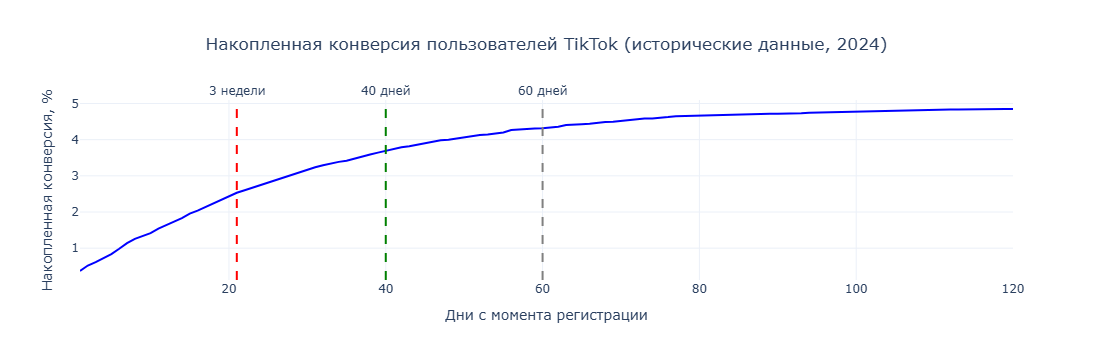

In [16]:
# Выделяем пользователей ТикТок за 2024 год
all_tiktok_users = pa_marketplace_users_AB[(pa_marketplace_users_AB['acq_channel'] == 'TikTok') &
    (pa_marketplace_users_AB['registration_date'] < '2025-01-01')][['user_id', 'registration_date']].copy()

# Добавляем информацию о покупках
all_tiktok_users = all_tiktok_users.merge(first_orders_tiktok[['user_id', 'time_to_first_order']], on='user_id', how='left')
all_tiktok_users['days_to_purchase'] = all_tiktok_users['time_to_first_order'].dt.days

# Считаем накопленную конверсию по дням с момента регистрации пользователя 
max_day = 120
cumulative_conv = []
total_users = len(all_tiktok_users)

for day in range(1, max_day + 1):
    bought_by_day = (all_tiktok_users['days_to_purchase'] <= day).sum()
    cumulative_conv.append(bought_by_day / total_users * 100)

# Строим график
fig = go.Figure()

fig.add_trace(go.Scatter(x=list(range(1, max_day + 1)),
                         y=cumulative_conv,
                         mode='lines',
                         name='Кумулятивная конверсия',
                         line=dict(color='blue', width=2)))

# Отмечаем ключевые дни
fig.add_vline(x=21, line_dash="dash", line_color="red", 
              annotation_text="3 недели", annotation_position="top")
fig.add_vline(x=40, line_dash="dash", line_color="green", 
              annotation_text="40 дней", annotation_position="top")
fig.add_vline(x=60, line_dash="dash", line_color="gray", 
              annotation_text="60 дней", annotation_position="top")

fig.update_layout(title="Накопленная конверсия пользователей TikTok (исторические данные, 2024)",
                  title_x=0.5,
                  xaxis_title="Дни с момента регистрации",
                  yaxis_title="Накопленная конверсия, %",
                  template="plotly_white",
                  hovermode="x unified")

fig.show()

3-недельный период наблюдения — это слишком короткий срок для оценки конверсии без стимулирования. Исторические данные TikTok показывают:
- Медианное время до первой покупки составляет 21 день
- 25% пользователей покупают позже 40 дней
- Уровень конверсии для месячных когорт TikTok исторически составляет 3–6%
- Ожидаемый уровнь конверсии в контрольной группе ~2,5%

Это означает:
- При 3-недельном окне мы заведомо не успеваем зафиксировать значительную часть естественных покупок в контрольной группе
- Rolling split в течение всего периода эксперимента дает дополнительный негативный эффект на конверсию и снижает чувствительность теста

**Вывод:** текущий дизайн эксперимента (3 недели + rolling split) **методологически некорректен** для оценки влияния бонуса на итоговую конверсию. Он скорее говорит о скорости совершения первой покупки, а не фактическое изменение итоговой конверсии в покупку. Для оценки реального эффекта бонуса требуется продление наблюдения до 40-50 дней.

### Проверка корректности сплитования

Для корректной интерпретации результатов эксперимента необходимо убедиться, что распределение пользователей между группами было случайным и группы сопоставимы по ключевым характеристикам:

- Размер групп и равномерность распределения
- Сопоставимость по возрасту, полу и региону
- Равномерность сплита по дням регистрации (с учетом rolling split)

#### Распределение пользователей по группам

In [17]:
# Определяем размеры групп
split = users_ab.groupby('group', as_index=False)['user_id'].count()
split['share'] = (split['user_id'] / split['user_id'].sum()).round(3)
display(split)

,group,user_id,share
0,control,1187,0.514
1,treatment,1123,0.486


Фактический сплит пользователей составил 51,4% / 48,6%.

In [18]:
# Проверяем стат значимость отклонения размеров выборок
observed = [split['user_id'][0], split['user_id'][1]]
expected = [split['user_id'].sum() / 2, split['user_id'].sum() / 2]

chi2, p_value = chi2_contingency([observed, expected])[:2]
print(f"p-value: {p_value:.4f}")
print(f"Различия статистически значимы: {p_value < 0.05}")

p-value: 0.3616
Различия статистически значимы: False


#### Сравнение групп по возрасту, полу и региону

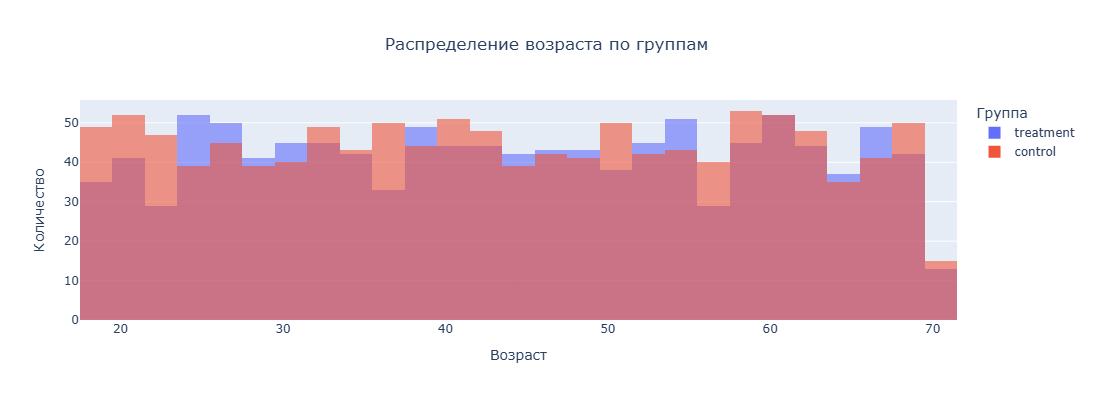

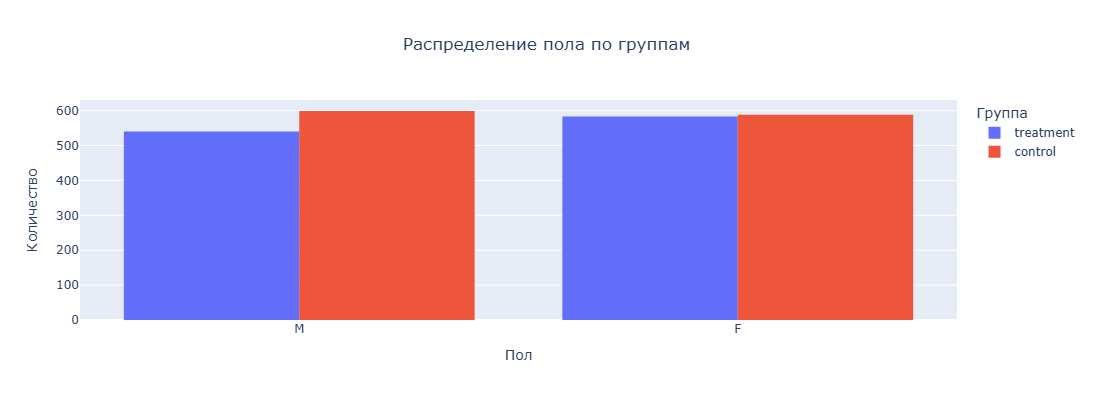

In [19]:
# Визуализируем распределение пользователей по возрасту в разрезе групп
fig = px.histogram(users_ab, 
                   x='age', 
                   color='group',
                   nbins=30,
                   barmode='overlay',
                   opacity=0.6,
                   title='Распределение возраста по группам',
                   labels={'age': 'Возраст', 'count': 'Количество пользователей', 'group': 'Группа'})
fig.update_layout(title_x=0.5, yaxis=dict(title='Количество'), height=400)
fig.show()

# Визуализируем распределение по полу для каждой группы
fig1 = px.histogram(users_ab, 
                    x='gender', 
                    color='group',
                    nbins=30,
                    barmode='group',
                    title='Распределение пола по группам',
                    labels={'gender': 'Пол', 'count': 'Количество пользователей', 'group': 'Группа'})
fig1.update_layout(title_x=0.5, yaxis=dict(title='Количество'), height=400)
fig1.show()

In [20]:
# Проверяем стат значимость различий возраста между группами
age_stats = users_ab.groupby('group')['age'].agg(['mean', 'median', 'std', 'min', 'max']).round(1)
display(age_stats)

group_a = users_ab[users_ab['group'] == 'control']['age']
group_b = users_ab[users_ab['group'] == 'treatment']['age']

t_stat, p_value = ttest_ind(group_a, group_b)
print(f"\nT-test p-value: {p_value:.4f}")
print(f"Различия статистически значимы: {p_value < 0.05}\n")

# Проверям стат значимость различий пола между группами
women_control = users_ab[users_ab['group'] == 'control']['gender'].value_counts().get('F', 0)
women_treatment = users_ab[users_ab['group'] == 'treatment']['gender'].value_counts().get('F', 0)

n_control = len(users_ab[users_ab['group'] == 'control'])
n_treatment = len(users_ab[users_ab['group'] == 'treatment'])

count = [women_control, women_treatment]
nobs = [n_control, n_treatment]

z_stat, p_value = proportions_ztest(count, nobs)
print(f"Доля женщин в control: {women_control/n_control:.2%}")
print(f"Доля женщин в treatment: {women_treatment/n_treatment:.2%}")
print(f"Z-тест p-value: {p_value:.4f}")
print(f"Различия статистически значимы: {p_value < 0.05}")

,mean,median,std,min,max
group,,,,,
control,43.7,43.0,15.3,18,70
treatment,44.1,44.0,15.1,18,70



T-test p-value: 0.5210
Различия статистически значимы: False

Доля женщин в control: 49.54%
Доля женщин в treatment: 51.91%
Z-тест p-value: 0.2532
Различия статистически значимы: False


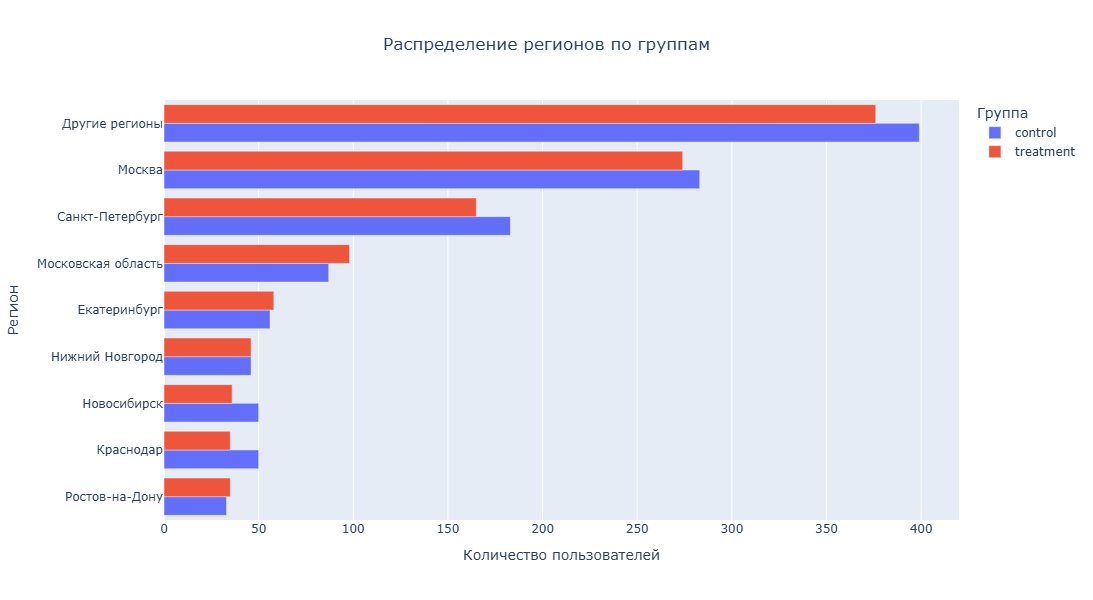

In [21]:
# Визуализируем сплитование по регионам
regions_df = users_ab.groupby(['region', 'group'], as_index=False, observed=True)['user_id'].count()
fig = px.bar(regions_df,
             y='region',
             x='user_id',
             color='group',
             title='Распределение регионов по группам',
             labels={'region': 'Регион', 'user_id': 'Пользователи', 'group': 'Группа'},
             barmode='group',
             orientation='h')

#fig.update_traces(texttemplate='%{text:.1%}', textposition='inside')
fig.update_layout(title_x=0.5, height=600, xaxis_title='Количество пользователей', yaxis={'categoryorder':'total ascending'})

fig.show()

In [22]:
# Проверяем стат значимость различий по регионам
contingency_region = pd.crosstab(users_ab['group'], users_ab['region'])

display(contingency_region)

chi2, p_value, dof, expected = chi2_contingency(contingency_region)
print(f"Регион — p-value: {p_value:.4f}")
print(f"Различия значимы: {p_value < 0.05}")

region,Другие регионы,Екатеринбург,Краснодар,Москва,Московская область,Нижний Новгород,Новосибирск,Ростов-на-Дону,Санкт-Петербург
group,,,,,,,,,
control,399,56,50,283,87,46,50,33,183
treatment,376,58,35,274,98,46,36,35,165


Регион — p-value: 0.6848
Различия значимы: False


#### Ежедневная динамика сплита

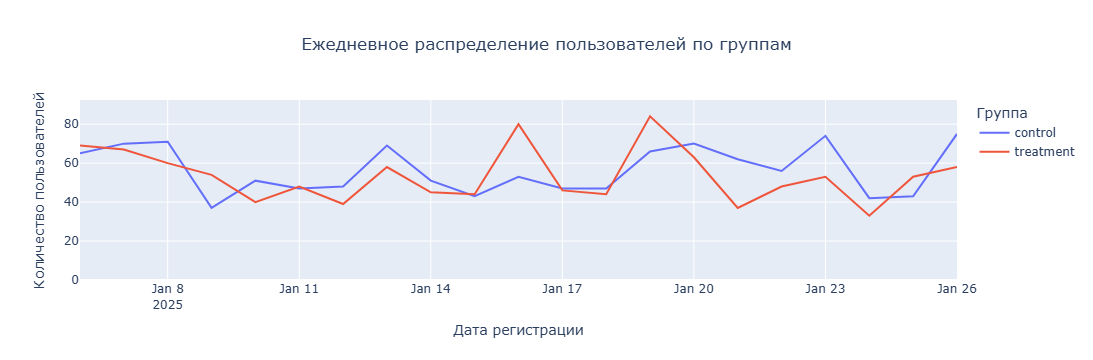

In [23]:
# Группируем по дате регистрации и группе
daily_groups = users_ab.groupby(['reg_dt', 'group']).size().reset_index(name='count')

# Визуализация
fig = px.line(daily_groups,
              x='reg_dt',
              y='count',
              color='group',
              title='Ежедневное распределение пользователей по группам',
              labels={'reg_dt': 'Дата регистрации', 'count': 'Количество пользователей', 'group': 'Группа'})
fig.update_layout(title_x=0.5, yaxis=dict(range=[0, 1.1 * daily_groups['count'].max()]))
fig.show()

In [24]:
# Проверка стат значимости различий сплита по дням
contingency_split = pd.crosstab(users_ab['group'], users_ab['reg_dt'])

display(contingency_split)

chi2, p_value, dof, expected = chi2_contingency(contingency_split)
print(f"Сплит по дням — p-value: {p_value:.4f}")
print(f"Различия значимы: {p_value < 0.05}")

reg_dt,2025-01-06,2025-01-07,2025-01-08,2025-01-09,2025-01-10,2025-01-11,2025-01-12,2025-01-13,2025-01-14,2025-01-15,...,2025-01-17,2025-01-18,2025-01-19,2025-01-20,2025-01-21,2025-01-22,2025-01-23,2025-01-24,2025-01-25,2025-01-26
group,,,,,,,,,,,,,,,,,,,,,
control,65,70,71,37,51,47,48,69,51,43,...,47,47,66,70,62,56,74,42,43,75
treatment,69,67,60,54,40,48,39,58,45,44,...,46,44,84,63,37,48,53,33,53,58


Сплит по дням — p-value: 0.0886
Различия значимы: False


#### Выводы о корректности сплитования
Группы статистически неразличимы, сплитование выполнено корректно.
- Общее распределение: control — 1 187 пользователя (51,6%), treatment — 1 123 пользователей (48,6%)
- По ключевым атрибутам (возраст, пол, регион) статистически значимых различий между группами не обнаружено
- Ежедневное распределение: наблюдаются небольшие колебания, характерные для rolling split с небольшой дневной выборкой (40–80 пользователей), но общая рандомизация соблюдена.

Ограничения:<br>
Проверка сопоставимости групп по типу устройства и операционной системе невозможна, так как эти данные отсутствуют в таблице пользователей и доступны только для активных пользователей.

### Оценка результатов эксперимента

Для оценки результатов A/B-теста необходимо выполнить анализ ключевых показателей эффективности в разрезе контрольной и тестовой групп.<br>
Будут оценены:
- целевая метрика — конверсия в первую покупку
- вспомогательные метрики — ARPU, ARPPU, AOV
- барьерная метрика — общая выручка

#### Подготовка данных

In [25]:
# Добавляем пользователям информацию о заказах
agg_orders = (orders_ab.groupby('user_id', as_index=False).agg(cnt_orders=('agg_order_id', 'nunique'),
                                                              first_order_dt=('order_date', 'min'),
                                                               gmv=('total_price', 'sum'),
                                                               revenue=('commission', 'sum')))

users_ab_stat = users_ab.merge(agg_orders, on='user_id', how='left')

users_ab_stat[['cnt_orders', 'gmv', 'revenue']] = users_ab_stat[['cnt_orders', 'gmv', 'revenue']].fillna(0)

users_ab_stat['time_to_first_order'] = users_ab_stat['first_order_dt'] - users_ab_stat['registration_date']

users_ab_stat['is_payer'] = users_ab_stat['cnt_orders'] > 0

display(users_ab_stat.head())

,user_id,registration_date,age,gender,region,acq_channel,cohort_week,cohort_month,group,reg_dt,cnt_orders,first_order_dt,gmv,revenue,time_to_first_order,is_payer
0,45848,2025-01-06 19:21:00,19,M,Санкт-Петербург,TikTok,2025-01-06,2025-01-01,treatment,2025-01-06,0.0,NaT,0.00,0.0,NaT,False
1,45849,2025-01-06 01:51:00,57,M,Санкт-Петербург,TikTok,2025-01-06,2025-01-01,treatment,2025-01-06,0.0,NaT,0.00,0.0,NaT,False
2,45850,2025-01-06 16:56:00,39,F,Ростов-на-Дону,TikTok,2025-01-06,2025-01-01,treatment,2025-01-06,0.0,NaT,0.00,0.0,NaT,False
3,45851,2025-01-06 13:14:00,32,M,Новосибирск,TikTok,2025-01-06,2025-01-01,treatment,2025-01-06,1.0,2025-01-14 00:45:41,2256.04,112.8,7 days 11:31:41,True
4,45853,2025-01-06 10:09:00,54,M,Москва,TikTok,2025-01-06,2025-01-01,control,2025-01-06,0.0,NaT,0.00,0.0,NaT,False


In [26]:
# Определяем метрики в разрезе групп
metrics_ab = users_ab_stat.groupby('group').agg(total_users=('user_id', 'count'),
                                              paying_users=('is_payer', 'sum'),
                                              cnt_orders=('cnt_orders', 'sum'),
                                              conversion=('is_payer', 'mean'),
                                              revenue=('revenue', 'sum'),
                                           gmv=('gmv', 'sum')).round(3)

metrics_ab['arpu'] = (metrics_ab['revenue'] / metrics_ab['total_users']).round(2)
metrics_ab['arppu'] = (metrics_ab['revenue'] / metrics_ab['paying_users']).round(2)
metrics_ab['aov'] = (metrics_ab['gmv'] / metrics_ab['cnt_orders']).round(2)
metrics_ab['orders_per_user'] = (metrics_ab['cnt_orders'] / metrics_ab['paying_users']).round(2)

metrics_ab_final = metrics_ab[['conversion', 'arpu', 'arppu', 'aov', 'revenue',
                               'paying_users', 'cnt_orders', 'orders_per_user']].T
metrics_ab_final.columns.name = None
metrics_ab_final.columns = metrics_ab_final.columns.astype(str)

metrics_ab_final['abs_diff'] = metrics_ab_final['treatment'] - metrics_ab_final['control']
metrics_ab_final['rel_diff'] = ((metrics_ab_final['treatment'] - metrics_ab_final['control']) / metrics_ab_final['control']).apply(lambda x: f"{x:+.1%}")

display(metrics_ab_final)

,control,treatment,abs_diff,rel_diff
conversion,0.007,0.066,0.059,+842.9%
arpu,9.990,106.860,96.870,+969.7%
arppu,1482.710,1621.670,138.960,+9.4%
aov,29654.150,30000.870,346.720,+1.2%
revenue,11861.690,120003.460,108141.770,+911.7%
paying_users,8.000,74.000,66.000,+825.0%
cnt_orders,8.000,80.000,72.000,+900.0%
orders_per_user,1.000,1.080,0.080,+8.0%


Все необходимые метрики рассчитаны для контрольной и тестовой групп.<br>
Стоит отметить, что конверсия в контрольной группе (0,7%) оказалась значительно ниже исторического ожидания для TikTok за первые 21 день (∼2,5%). Это может быть связано с сезонностью (январь — низкий спрос после праздников) или изменением качества трафика. В любом случае, контрольная группа не является типичной, что усиливает неопределённость выводов и необходимость перезапуска теста.

#### Гипотезы для проверки метрик эксперимента

1. **Конверсия (целевая метрика)**
   - **H₀:** Бонус не увеличивает конверсию (конверсия_treatment ≤ конверсия_control)
   - **H₁:** Бонус увеличивает конверсию (конверсия_treatment > конверсия_control)
   - **Тест:** proportions_ztest(alternative='larger')
   

2. **ARPU (средняя выручка на пользователя)**
   - **H₀:** Бонус не увеличивает ARPU (ARPU_treatment ≤ ARPU_control)
   - **H₁:** Бонус увеличивает ARPU (ARPU_treatment > ARPU_control)
   - **Тест:** ttest_ind(alternative='greater')


3. **ARPPU (средняя выручка на платящего)**
   - **H₀:** Бонус не увеличивает на ARPPU (ARPPU_treatment ≤ ARPPU_control)
   - **H₁:** Бонус увеличивает ARPPU (ARPPU_treatment > ARPPU_control)
   - **Тест:** ttest_ind(alternative='greater')
   

4. **AOV (средний чек)**
   - **H₀:** Бонус не увеличивает средний чек (AOV_treatment  ≤ AOV_control)
   - **H₁:** Бонус увеличивает средний чек (AOV_treatment > AOV_control)
   - **Тест:** ttest_ind(alternative='greater')
   
   
5. **Общая выручка (барьерная метрика)**
    - **H₀:** Бонус не увеличивает общую выручку (выручка_treatment ≤ выручка_control)
    - **H₁:** Бонус увеличивает общую выручку (выручка_treatment > выручка_control)
    - **Тест:** бутстрап для разницы сумм

#### Оценка статистической значимости

In [27]:
# Считаем p-value для каждой метрики
p_values = {}


# Ключевая метрика: конверсия в покупку
control_n = metrics_ab.loc['control', 'total_users']
treatment_n = metrics_ab.loc['treatment', 'total_users']

control_payers = metrics_ab.loc['control', 'paying_users']
treatment_payers = metrics_ab.loc['treatment', 'paying_users']

count = [ treatment_payers, control_payers,]
nobs = [treatment_n, control_n, ]

_, p_values['conversion'] = proportions_ztest(count, nobs,  alternative='larger')


# Вспомогательная метрика: АRPU 
control_arpu = users_ab_stat.query('group == "control"')['revenue']
test_arpu = users_ab_stat.query('group == "treatment"')['revenue']

_, p_values['arpu'] = ttest_ind(test_arpu, control_arpu, equal_var=False, alternative='greater')

# Вспомогательная метрика: АRPPU
control_arppu = users_ab_stat.query('group == "control" & is_payer == True')['revenue']
test_arppu = users_ab_stat.query('group == "treatment" & is_payer == True')['revenue']

_, p_values['arppu'] = ttest_ind(test_arppu, control_arppu, equal_var=False, alternative='greater')


# Вспомогательная метрика: AOV (через линеаризацию)
aov_control = metrics_ab_final.loc['aov', 'control']

users_ab_stat['linearized_aov'] = users_ab_stat['gmv'] - aov_control * users_ab_stat['cnt_orders']

control_linear = users_ab_stat.query('group == "control"')['linearized_aov']
treatment_linear = users_ab_stat.query('group == "treatment"')['linearized_aov']

_, p_values['aov'] = ttest_ind(control_linear, treatment_linear, equal_var=False, alternative='greater')

# Барьерная метрика: выручка
np.random.seed(42)

control_rev = users_ab_stat.query('group == "control"')['revenue']
treatment_rev = users_ab_stat.query('group == "treatment"')['revenue']

diffs = []
for _ in range(1000):
    sample_control = np.random.choice(control_rev, size=len(control_rev), replace=True)
    sample_treatment = np.random.choice(treatment_rev, size=len(treatment_rev), replace=True)
    diffs.append(sample_treatment.sum() - sample_control.sum())

diffs = np.array(diffs)
p_values['revenue'] = (diffs <= 0).mean()


# Добавляем p_value к метрикам
metrics_ab_final['p_value'] = pd.Series(p_values)
display(metrics_ab_final)

,control,treatment,abs_diff,rel_diff,p_value
conversion,0.007,0.066,0.059,+842.9%,7.966801e-15
arpu,9.990,106.860,96.870,+969.7%,2.296080e-06
arppu,1482.710,1621.670,138.960,+9.4%,3.694870e-01
aov,29654.150,30000.870,346.720,+1.2%,5.301730e-01
revenue,11861.690,120003.460,108141.770,+911.7%,0.000000e+00
paying_users,8.000,74.000,66.000,+825.0%,NaN
cnt_orders,8.000,80.000,72.000,+900.0%,NaN
orders_per_user,1.000,1.080,0.080,+8.0%,NaN


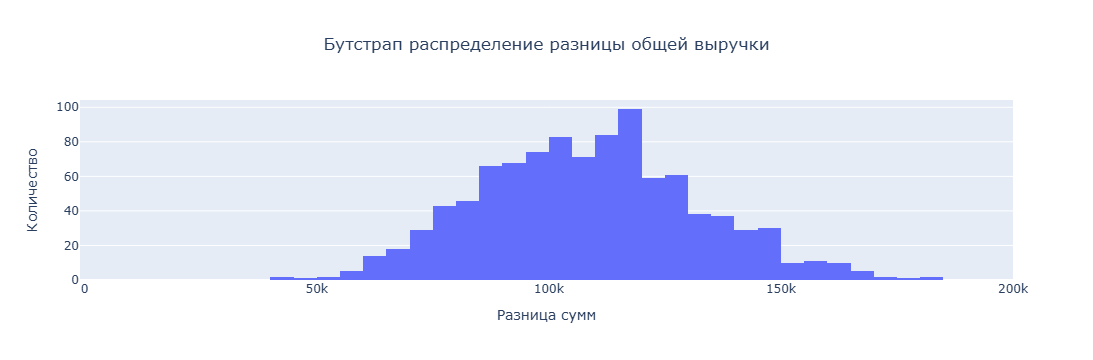

In [28]:
# Визуалзируем бустрап распределение разниц выручки
fig = px.histogram(diffs, title='Бутстрап распределение разницы общей выручки')
fig.update_layout(xaxis=dict(title='Разница сумм', range=[-1000, 200000]), yaxis=dict(title='Количество'))
fig.update_layout(title_x=0.5, showlegend=False)
fig.show()

#### Выводы по результатам эксперимента
***Целевая метрика: конверсия в первую покупку***<br>
Бонус оказал значимое влияние на конверсию.<br>
В тестовой группе доля пользователей, совершивших первую покупку, оказалась выше, чем в контрольной. Разница статистически значима (p < 0,001).<br>
Гипотеза подтвердилась: бонус стимулирует пользователей TikTok к оформлению первого заказа.<br>

***ARPU (выручка на пользователя)***<br>
Средняя выручка на пользователя значимо выросла.<br>
Это ожидаемый эффект, учитывая рост конверсии. При этом увеличение ARPU произошло без снижения качества покупательской способности аудитории.<br>
Гипотеза подтвердилась.<br>

***ARPPU (средняя выручка на платящего) и AOV (средний чек)***<br>
Статистически значимых различий не обнаружено:
- ARPPU: p_value = 0,369 → различия не значимы
- AOV: p_value = 0,530 → различия не значимы

Бонус не привел к ухудшению качества платящей аудитории: средний чек и выручка на платящего пользователя остались на уровне контрольной группы.

***Барьерная метрика: общая выручка***<br>
Общая выручка в тестовой группе составила 120,0 тыс. у.е., что в 10 раз превышает показатель контрольной группы (11,9 тыс. у.е.). Разница статистически значима (p < 0,001). Барьерная метрика пройдена: бонус не навредил бизнесу, а привел к кратному росту выручки в тестовой группе.

## Экономический контекст (оценка юнит-экономики теста)
Для полноценной оценки эффективности бонуса необходимо учитывать не только рост конверсии, но и экономику канала. В данных эксперимента отсутствует информация о затратах на бонус, что делает расчёты более оптимистичными. Ниже приведена приблизительная оценка на основе доступных данных (бюджет на привлечение, выручка, количество пользователей).

In [29]:
# Маркетинговый бюджет TikTok за январь
# Из таблицы campaign_costs, где spend_month = январь 2025
budget_jan = pa_marketplace_campaign_costs[(pa_marketplace_campaign_costs['spend_month'] == '2025-01-01') &
    (pa_marketplace_campaign_costs['acq_channel'] == 'TikTok')]['budget'].sum()
print(f"Маркетинговый бюджет TikTok за январь: {budget_jan:.0f} у.е.")

# Общее количество пользователей TikTok в тесте за 3 недели
total_tiktok_users = len(users_ab[users_ab['acq_channel'] == 'TikTok'])
print(f"Всего пользователей TikTok в тесте (6–26 янв): {total_tiktok_users}")

# Количество пользователей в тестовой группе (B)
treatment_users = len(users_ab[(users_ab['acq_channel'] == 'TikTok') & (users_ab['group'] == 'treatment')])
print(f"Пользователей в тестовой группе (B): {treatment_users}")

# Выручка маркетплейса с тестовой группы
treatment_orders = orders_ab.merge(users_ab[['user_id', 'group']], on='user_id', how='inner')
treatment_orders = treatment_orders[treatment_orders['group'] == 'treatment']
revenue_treatment = treatment_orders['commission'].sum()
print(f"Выручка маркетплейса с тестовой группы (B): {revenue_treatment:.0f} у.е.")

# ARPU в тестовой группе
arpu_treatment = revenue_treatment / treatment_users
print(f"ARPU в тестовой группе (B): {arpu_treatment:.2f} у.е.")

Маркетинговый бюджет TikTok за январь: 1292709 у.е.
Всего пользователей TikTok в тесте (6–26 янв): 2310
Пользователей в тестовой группе (B): 1123
Выручка маркетплейса с тестовой группы (B): 120003 у.е.
ARPU в тестовой группе (B): 106.86 у.е.


### Оценка ROMI для тестовой гоуппы
На основе данных за период эксперимента (6–26 января 2025) можно сделать приблизительную оценку.

| Показатель | Значение |
|---|---|
| Маркетинговый бюджет TikTok за январь | 1 292 709 у.е. |
| Всего пользователей TikTok в тесте (6–26 янв) | 2 310 |
| Пользователей в тестовой группе (B) | 1 123 |
| Выручка маркетплейса с тестовой группы (B) | 120 003 у.е. |
| ARPU в тестовой группе (B) | 106,86 у.е. |

**Оценка затрат на привлечение в тестовой группе (пропорционально):**  
Бюджет на тестовую группу ≈ (1 123 / 2 310) × 1 292 709 ≈ **628 000 у.е.**

**ROAS (Return on Ad Spend) без учёта затрат на бонус:**  
ROAS = Выручка / Бюджет = 120 003 / 628 000 ≈ **0,19** (каждый рубль затрат приносит 19 копеек выручки).  
Без учёта затрат на бонус канал остаётся глубоко убыточным.

**ROMI (без учёта затрат на бонус):**  
ROMI = (Выручка − Бюджет) / Бюджет = (120 003 − 628 000) / 628 000 ≈ **−0,81** (–81%).

**С учётом затрат на бонус** (данные отсутствуют) ROMI будет ещё ниже.

**Вывод:** даже при значительном росте конверсии и выручки канал TikTok остаётся убыточным. Масштабирование бонуса без улучшения юнит-экономики (снижение CAC, повышение AOV, рост повторных покупок) нецелесообразно. Рекомендуется пилотный запуск на 10–20% трафика с полноценным сбором экономических метрик (затраты на бонус, ROMI, срок окупаемости).

### Оценка срока окупаемости (приблизительная)

**Исходные данные (тест, группа B):**

- Пользователей в тестовой группе: 1 123
- Выручка маркетплейса: 120 003 у.е.
- ARPU (за 3 недели): 106,86 у.е.

**Годовая проекция ARPU (если бы темп сохранялся):**  
106,86 × (52 / 3) ≈ **1 853 у.е.** в год на одного привлечённого пользователя.

**Оценка CAC (стоимость привлечения) для тестовой группы:**  
Бюджет TikTok за январь (1 292 709 у.е.) распределён на всех пользователей (2 310). На тестовую группу приходится ≈ 628 000 у.е.  
CAC ≈ 628 000 / 1 123 ≈ **560 у.е.**

**Срок окупаемости (грубо):**  
CAC / ARPU_год × 12 месяцев ≈ 560 / 1 853 × 12 ≈ **3,6 месяца**.

**Но это без учёта затрат на бонус.** Если добавить хотя бы 100 у.е. бонуса на каждого пользователя тестовой группы (гипотетически), CAC вырастет до 660 у.е., а срок окупаемости — до **4,3 месяца**.

**С учётом того, что конверсия в тесте (6,6%) всё ещё ниже, чем у эффективных каналов (30–40%), и повторные покупки не гарантированы, реальный срок окупаемости может составить 6–12 месяцев и более.**

**Вывод:** даже с бонусом канал не становится быстро окупаемым. Решение о масштабировании должно учитывать не только конверсию, но и экономику.

## Ключевые выводы и рекомендации

### Что показал тест

1. **Статистически значимый рост конверсии**<br>
За 3-недельный период наблюдения конверсия в тестовой группе составила 6,6%, в контрольной — 0,7% (p < 0,001). Средняя выручка на пользователя (ARPU) значимо выросла с 10,0 у.е. до 106,9 у.е. (p < 0,001). Общая выручка в тестовой группе составила 120,0 тыс. у.е., что в 10 раз выше контрольной (11,9 тыс. у.е.), разница статистически значима (p < 0,001). Статистически значимых различий по ARPPU (p = 0,369) и AOV (p = 0,470) не обнаружено.


2. **Результат превосходит исторический максимум**<br>
За 3 недели эксперимента конверсия в тестовой группе (6,6%) превысила результат лучшей когорты TikTok 2024 года (6,2% для июльских пользователей). Это указывает на потенциально высокую эффективность бонуса.

3. **Экономика канала остаётся убыточной**<br>  
Даже с учётом роста конверсии юнит-экономика TikTok остаётся отрицательной.  
    - ROAS ≈ 0,19 (1 рубль затрат приносит 19 копеек выручки)  
    - ROMI ≈ –81% (без учёта затрат на бонус; с учётом бонуса убыток ещё больше)  
    - Оценочный срок окупаемости — от 4 месяцев (без бонуса) до 6–12 месяцев и более (с учётом бонуса и нестабильности повторных покупок)<br><br>

4. **Методологические ограничения дизайна**<br>
Однако ввиду ограничений дизайна эксперимента (rolling split, короткий период наблюдения, старт в праздники) данные результаты не позволяют сделать однозначных выводов о влиянии бонуса на итоговую конверсию. Исторические данные TikTok показывают, что медианное время до первой покупки составляет 21 день, а 25% пользователей покупают позже 40 дней. При 3-недельном окне и постепенном наборе пользователей контрольная группа могла не успеть показать свою естественную конверсию в полном объеме. Для оценки влияния бонуса на итоговую конверсию необходимо анализировать не только конверсию на фиксированном окне, но и динамику её насыщения.

### Ограничения, которые нельзя игнорировать

- Для оценки влияния бонуса на итоговую конверсию необходимо анализировать динамику насыщения, а не только конверсию на фиксированном окне. При 3-недельном наблюдении кривая конверсии в контрольной группе ещё не вышла на плато, что не позволяет отделить эффект ускорения от эффекта увеличения итоговой конверсии.


- Rolling split не подходит для продукта с медленной конверсией. Этот дизайн предполагает, что эффект можно измерить в течение короткого окна наблюдения (3 недели). Однако исторические данные TikTok показывают, что медианное время до первой покупки составляет 21 день, а 25% пользователей покупают позже 40 дней. При таком поведенческом цикле rolling split приводит к систематическому смещению: пользователи, зарегистрировавшиеся позже, имеют меньше времени для совершения покупки, что делает невозможным корректную оценку итоговой конверсии.


- Исключение первых 5 дней эксперимента. Эксперимент стартовал 1 января, в разгар новогодних праздников. Для минимизации влияния аномального пользовательского поведения из анализа были исключены данные за 1–5 января. Анализируемый период составил 6–26 января. Это решение позволило снизить риски искажения результатов, но сузило окно наблюдения и сократило выборку.

- Конверсия в контрольной группе (0,7%) оказалась значительно ниже исторического ожидания (∼2,5% за первые 21 день). Это может быть связано с сезонностью (январь — низкий спрос) или изменением качества трафика. В любом случае, контрольная группа не является типичной, что усиливает неопределённость выводов.

- Малая выборка платящих в контрольной группе (8 человек) не позволяет оценить влияние на ARPPU и AOV. При этом статистические тесты для ARPPU и AOV не выявили значимых различий, что свидетельствует об отсутствии ухудшения качества платящей аудитории.

### Рекомендации бизнесу

1. **Не масштабировать бонус на весь канал без дополнительных проверок.**  
   Даже при росте конверсии юнит-экономика TikTok остаётся убыточной (ROAS ≈ 0,19, ROMI ≈ –81%). Полный роллаут приведёт к неоправданным затратам.

2. **Запустить пилотный проект с системой мониторинга.**  
   - Внедрить бонус на 10–20% трафика TikTok, сохранив контрольную группу без бонуса.  
   - Наблюдать за динамикой конверсии на горизонте 40–50 дней.  
   - Собрать данные о затратах на бонус, полной выручке и повторных покупках.  
   - Принять решение о масштабировании только при выполнении условий:  
     - разница в конверсии сохраняется после выхода на плато;  
     - ARPPU и AOV не снижаются;  
     - повторные покупки не падают;  
     - ROMI становится положительным (или срок окупаемости приемлем для бизнеса).

3. **Параллельно улучшать юнит-экономику канала.**  
   - Снижать CAC (пересмотреть таргетинг, ставки).  
   - Повышать AOV (кросс-продажи, пакетные предложения).  
   - Стимулировать повторные покупки (программа лояльности, ретаргетинг).

4. **Перезапустить эксперимент с корректным дизайном (альтернативный вариант).**  
   - Увеличить период наблюдения до 40–50 дней.  
   - Исключить праздничные периоды из дат старта.  
   - Использовать классический A/B-тест с фиксированными группами вместо rolling split.  
   - Заранее рассчитать необходимый размер выборки (power analysis).

5. **Для будущих экспериментов утверждать дизайн до запуска.**  
   - Фиксировать период наблюдения, соответствующий поведенческому циклу пользователей.  
   - Исключать аномальные периоды (праздники, распродажи).  
   - Рассчитывать необходимый размер выборки (power analysis) перед запуском.

6. **Доработать систему сбора данных.**  
   - Логировать тип устройства (device) и операционную систему (os) на этапе регистрации пользователя.  
   - Это позволит проверять корректность сплита по этим признакам и своевременно выявлять технические проблемы, влияющие на эксперимент.